# Week 7 · Day 2 — Class: Telling a Story with Data, and Meeting Streamlit

Yesterday you learned to *make* charts. Today you learn to *use* them well:

1. **Storytelling** — choosing the right chart so a chart makes a clear point.
2. **Streamlit** — a tool that turns a Python script into a real web page.

We keep using the Gapminder dataset.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../Day1/data/gapminder.csv")
df_2007 = df[df["year"] == 2007]
print("Ready. 2007 rows:", len(df_2007))

Ready. 2007 rows: 142


## 1. Every chart should make ONE point

A chart is not decoration. Before you draw anything, ask:

> **What is the one message I want the viewer to walk away with?**

Then choose the chart that shows that message most clearly.

| Your question | Best chart |
|---------------|-----------|
| How did something change over time? | **Line** |
| Which group is bigger / smaller? | **Bar** |
| Are two numbers related? | **Scatter** |
| How is one number spread out? | **Histogram** |


## 2. Right chart vs wrong chart

Suppose the message is: *"Europe lives longer than Africa on average."*
That is a **comparison of groups**, so a **bar chart** is right.

A scatter plot of the same data would hide the message. Let's see both.

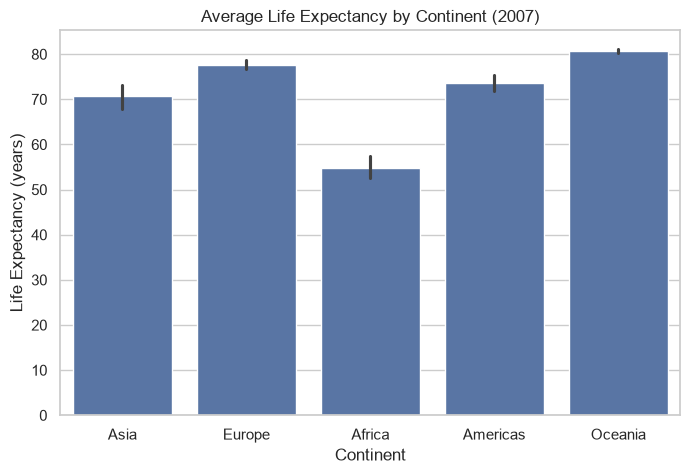

In [2]:
# RIGHT: a bar chart makes the comparison obvious
plt.figure(figsize=(8, 5))
sns.barplot(data=df_2007, x="continent", y="lifeExp")
plt.title("Average Life Expectancy by Continent (2007)")
plt.xlabel("Continent")
plt.ylabel("Life Expectancy (years)")
plt.show()

The bar chart answers the question in one glance. Pick the chart that fits the message.

## 3. Comparing groups inside one chart with `hue`

Seaborn's `hue` lets you split any chart by a category.
Here is income vs life expectancy, coloured by continent — one chart, five stories.

In [3]:
df_2007

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,"Yemen, Rep.",2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


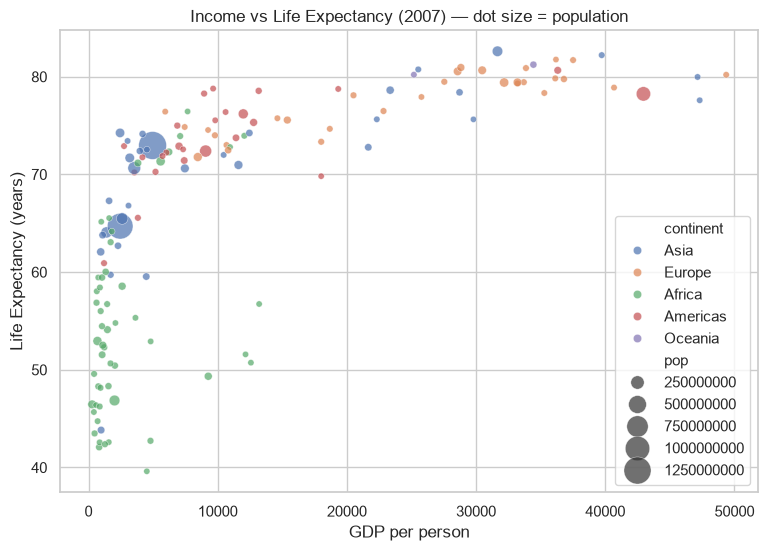

In [4]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_2007, x="gdpPercap", y="lifeExp",
                hue="continent", size="pop", sizes=(20, 400), alpha=0.7)
plt.title("Income vs Life Expectancy (2007) — dot size = population")
plt.xlabel("GDP per person")
plt.ylabel("Life Expectancy (years)")
plt.show()

Now the chart tells several things at once: richer countries live longer (position),
which continent each country is on (colour), and how big it is (dot size).
This single chart is a whole data story.

## 4. Annotate to highlight the insight

A short label pointing at the key part of a chart guides the viewer's eye.
Let's mark the country with the highest life expectancy in 2007.

In [6]:
df_2007['lifeExp'].nlargest(1)

803    82.603
Name: lifeExp, dtype: float64

In [8]:
df_2007.loc[df_2007['lifeExp'].idxmax()]

country            Japan
year                2007
pop          127467972.0
continent           Asia
lifeExp           82.603
gdpPercap    31656.06806
Name: 803, dtype: object

Highest life expectancy in 2007: Japan 82.6


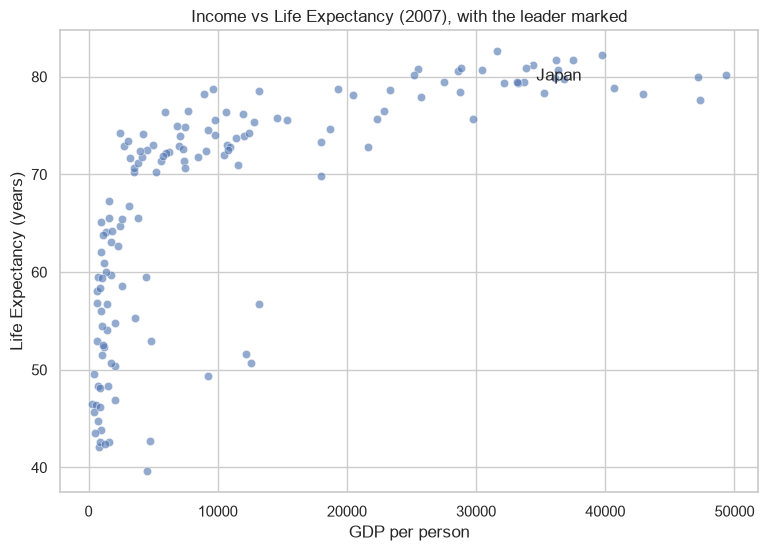

In [9]:
top = df_2007.loc[df_2007["lifeExp"].idxmax()]
print("Highest life expectancy in 2007:", top["country"], round(top["lifeExp"], 1))

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_2007, x="gdpPercap", y="lifeExp", alpha=0.6)

# Add a text label at that country's point
plt.annotate(top["country"],
             xy=(top["gdpPercap"], top["lifeExp"]),
             xytext=(top["gdpPercap"] + 3000, top["lifeExp"] - 3),
             arrowprops=dict(arrowstyle="->"))

plt.title("Income vs Life Expectancy (2007), with the leader marked")
plt.xlabel("GDP per person")
plt.ylabel("Life Expectancy (years)")
plt.show()

## 5. Meet Streamlit — from script to web app

So far your charts live inside a notebook. **Streamlit** turns a plain Python
script into a web page that anyone can open in a browser — no HTML needed.

You write normal Python, add a few `st.` commands, and Streamlit builds the page.

The most common commands:

| Command | What it shows |
|---------|---------------|
| `st.title("...")` | a big page title |
| `st.header("...")` | a section heading |
| `st.write("...")` | text, numbers, or a DataFrame |
| `st.dataframe(df)` | an interactive table |
| `st.pyplot(fig)` | a Matplotlib/Seaborn chart |
| `st.selectbox(...)` | a dropdown the user can pick from |
| `st.slider(...)` | a slider the user can drag |

**Important:** Streamlit apps do **not** run inside a notebook. They live in a
`.py` file and you start them from a terminal. We will write the file here and
run it tomorrow. Today, just understand the pieces.


## 6. A first Streamlit app (read it, don't run it here)

Below is a complete tiny Streamlit app. Read each line — it is just Python plus
`st.` commands. We save it to a file so you can see it, but we run it from a
terminal, not from the notebook.

In [ ]:
app_code = '''
import streamlit as st
import pandas as pd

st.title("My First Streamlit App")
st.write("Hello! This is a web page built with Python.")

df = pd.read_csv("gapminder.csv")
st.header("A peek at the data")
st.dataframe(df.head())
'''

# Save it to a file next to the notebook
with open("first_app.py", "w") as f:
    f.write(app_code)

print("Saved first_app.py")
print("To run it, you would type in a terminal:  streamlit run first_app.py")

When you run `streamlit run first_app.py` in a terminal, a browser tab opens
showing your title, your text, and an interactive table. That is a real web app,
built with the Python you already know.

## 7. Adding a chart to a Streamlit app

To show a Matplotlib/Seaborn chart in Streamlit you build a **figure object**
and pass it to `st.pyplot()`. Here is the pattern (again, saved to a file to read).

In [ ]:
chart_app = '''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.title("Gapminder Charts")

df = pd.read_csv("gapminder.csv")
df_2007 = df[df["year"] == 2007]

st.header("Life expectancy by continent (2007)")

# Build a figure and axes, draw on the axes, hand the figure to Streamlit
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_2007, x="continent", y="lifeExp", ax=ax)
ax.set_title("Average Life Expectancy by Continent (2007)")
ax.set_xlabel("Continent")
ax.set_ylabel("Life Expectancy (years)")

st.pyplot(fig)
'''

with open("chart_app.py", "w") as f:
    f.write(chart_app)

print("Saved chart_app.py")

Notice the small change from the notebook style: instead of `plt.figure()` and
`plt.show()`, we make `fig, ax = plt.subplots()`, draw using `ax`, and finish with
`st.pyplot(fig)`. Streamlit needs the **figure object** to put it on the page.

## 8. Recap

Today you learned:

- A chart should make **one clear point** — pick the chart type that fits the message
- `hue`, dot **size**, and **annotations** let one chart carry a richer story
- **Streamlit** turns a Python script into a web page using `st.` commands
- Charts go into Streamlit with `fig, ax = plt.subplots()` then `st.pyplot(fig)`
- Streamlit apps run from a **terminal** with `streamlit run app.py`, not inside a notebook

Tomorrow (Build & Ship): you will build the full **Gapminder Explorer** app with
interactive widgets and **deploy it live** to the internet.
